In [1]:
from pathlib import Path

# --- Helper: choose between macOS-style and Windows-style roots ---
def pick_path(mac_path_str, win_path_str):
    mac_p = Path(mac_path_str)
    win_p = Path(win_path_str)
    if mac_p.exists():
        return mac_p
    elif win_p.exists():
        return win_p
    else:
        # Neither exists; return mac version but warn
        print(f"WARNING: Neither {mac_p} nor {win_p} exists on this system.")
        return mac_p

# --- Roots for BPB_proc (Session ? / main) ---
bpb_root = pick_path("/Volumes/HD-B1/BPB_proc", "E:/BPB_proc")

# --- Roots for SES-1 ---
ses1_root = pick_path(
    "/Volumes/HD-B1/Thesis/SES-1_BIDS/derivatives/afni_proc",
    "E:/Thesis/SES-1_BIDS/derivatives/afni_proc"
)

# --- Collect subject dirs (names only, like MATLAB dir('sub-*.results')) ---
def list_subject_dirs(root: Path, pattern="sub-*.results"):
    # glob pattern; keep only directories
    return sorted([p for p in root.glob(pattern) if p.is_dir()])

subject_dirs_1_paths = list_subject_dirs(bpb_root)
subject_dirs_2_paths = list_subject_dirs(ses1_root)

# MATLAB `subject_dirs_1 = {subject_dirs.name};`
subject_dirs_1 = [p.name for p in subject_dirs_1_paths]
subject_dirs_2 = [p.name for p in subject_dirs_2_paths]

# MATLAB `subject_dirs_full_1 = cellfun(@(s) fullfile(...), ...)`
# We already have full Paths from the glob results:
subject_dirs_full_1 = [str(p) for p in subject_dirs_1_paths]
subject_dirs_full_2 = [str(p) for p in subject_dirs_2_paths]

# --- Merge (MATLAB [a, b]) ---
bp_subject_dirs = subject_dirs_1 + subject_dirs_2
print(bp_subject_dirs)
bp_subject_dirs_full = subject_dirs_full_1 + subject_dirs_full_2

['sub-1.results', 'sub-10.results', 'sub-11.results', 'sub-12.results', 'sub-13.results', 'sub-15.results', 'sub-16.results', 'sub-17.results', 'sub-18.results', 'sub-19.results', 'sub-2.results', 'sub-20.results', 'sub-21.results', 'sub-22.results', 'sub-23.results', 'sub-4.results', 'sub-5.results', 'sub-6.results', 'sub-7.results', 'sub-8.results', 'sub-24.results', 'sub-25.results', 'sub-26.results', 'sub-27.results', 'sub-28.results', 'sub-29.results', 'sub-30.results', 'sub-31.results', 'sub-32.results', 'sub-33.results', 'sub-34.results', 'sub-36.results', 'sub-37.results', 'sub-38.results', 'sub-39.results', 'sub-40.results', 'sub-41.results', 'sub-42.results']


In [3]:
from pathlib import Path
import numpy as np
import warnings

# Glasser ROI indices: 1:180 and 1001:1180 (inclusive)
ROI_INDICES = list(range(1, 181)) + list(range(1001, 1181))  # 360 total


def BoldRoi_Subjects(subj):
    """
    Build a 360 x T BOLD matrix for a single subject from AFNI .1D ROI time series.

    Parameters
    ----------
    subj : str or pathlib.Path
        Path to the *subject directory* that contains the subfolder
        'Zscore_data_bandpass' with files named 'BOLD_<index>.1D', where
        <index> spans 1-180 and 1001-1180.

    Returns
    -------
    BOLD_matrix : np.ndarray, shape (360, T)
        Row = ROI (360 total), Column = timepoint.
        Missing or unreadable files become NaN rows.
    """
    subj = Path(subj)
    folder = subj / "Zscore_data_bandpass"

    # Build list of file paths in ROI order
    filepaths = [folder / f"BOLD_{i}.1D" for i in ROI_INDICES]

    # Determine T (time length) from the first file that exists & loads
    T = None
    for fp in filepaths:
        if fp.is_file():
            try:
                arr = np.loadtxt(fp, ndmin=1)
            except Exception as e:
                warnings.warn(f"Could not read {fp}: {e}")
                continue
            arr = np.asarray(arr).squeeze()
            if arr.ndim == 0:
                arr = arr[None]
            elif arr.ndim > 1:
                # Flatten but warn: unexpected shape
                warnings.warn(f"{fp} has shape {arr.shape}; flattening to 1D.")
                arr = arr.reshape(-1)
            T = arr.size
            break

    if T is None:
        raise FileNotFoundError(
            f"No readable BOLD_*.1D files found in {folder}."
        )

    # Preallocate
    BOLD_matrix = np.full((len(ROI_INDICES), T), np.nan, dtype=float)

    # Load each ROI
    for row, fp in enumerate(filepaths):
        if fp.is_file():
            try:
                arr = np.loadtxt(fp, ndmin=1)
                arr = np.asarray(arr).squeeze()
                if arr.ndim == 0:
                    arr = arr[None]
                elif arr.ndim > 1:
                    warnings.warn(f"{fp} has shape {arr.shape}; flattening to 1D.")
                    arr = arr.reshape(-1)

                if arr.size != T:
                    warnings.warn(
                        f"{fp} length {arr.size} != expected {T}; "
                        "truncating/padding with NaN."
                    )
                    if arr.size > T:
                        arr = arr[:T]
                    else:
                        tmp = np.full(T, np.nan)
                        tmp[:arr.size] = arr
                        arr = tmp

                BOLD_matrix[row, :] = arr

            except Exception as e:
                warnings.warn(f"Error reading {fp}: {e}; filling with NaN.")
                # Row stays NaN
        else:
            warnings.warn(f"Missing file: {fp}; filling with NaN.")

    return BOLD_matrix



ImportError: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

In [3]:
# Suppose bp_subject_dirs_full is the merged list of subject directory *strings*
# (or Path objects) from the two roots, as shown previously.

BOLD_all_subjects_BP = [BoldRoi_Subjects(p) for p in bp_subject_dirs_full]
print(BOLD_all_subjects_BP)

# How many subjects?
n_subj = len(BOLD_all_subjects_BP)
print("N subjects:", n_subj)

# Check the first subject's matrix
print("First subject matrix shape:", BOLD_all_subjects_BP[0].shape)
print("First subject preview:\n", BOLD_all_subjects_BP[0][:5, :10])  # first 5 ROIs, 10 timepoints


[array([[ 0.256145, -0.041168, -0.12086 , ..., -0.002634, -0.033786,
         0.158722],
       [ 0.608073, -0.242999, -0.408318, ..., -0.5694  , -0.401144,
         0.662581],
       [ 0.785031, -0.004244, -0.471563, ...,  0.004966,  0.114299,
         0.709153],
       ...,
       [ 0.429095, -0.501431, -0.689352, ..., -0.275246, -0.149409,
         0.494838],
       [ 0.739472, -0.09611 , -0.915692, ...,  0.759714, -0.164551,
         0.114904],
       [-0.31531 ,  0.325854,  0.822305, ...,  0.480899,  0.027758,
        -0.412355]]), array([[-0.242657, -0.199818,  0.174392, ..., -0.095738, -0.0848  ,
        -0.074391],
       [ 0.037872,  0.476739,  0.520162, ...,  0.282731, -0.334801,
        -0.386018],
       [ 0.876739, -0.225953, -0.382351, ...,  0.299022, -0.725526,
         0.329756],
       ...,
       [ 0.247676,  0.259998,  0.054923, ...,  0.24978 ,  0.511099,
         0.322   ],
       [ 0.202561, -0.187302, -0.311077, ..., -0.219208, -0.098851,
         0.264528],
     

In [7]:
# Controls 
from pathlib import Path

# --- Helper reused from earlier ---
def pick_path(linux_path_str, mac_path_str):
    lin_p = Path(linux_path_str)
    mac_p = Path(mac_path_str)
    if lin_p.exists():
        return lin_p
    elif mac_p.exists():
        return mac_p
    else:
        print(f"WARNING: Neither {lin_p} nor {mac_p} exists; using Linux path string.")
        return lin_p  # fallback


# --- Root for HC subjects (Linux vs macOS given in MATLAB comments) ---
hc_root = pick_path(
    "E:/BIDS/derivatives/afni",
    "/Volumes/HD-B1/BIDS/derivatives/afni",
)

# --- Numeric subject IDs: MATLAB [35:38, 40:53, 55:57, 59:70] ---
subject_nums = (
    list(range(35, 39))  +  # 35-38 inclusive
    list(range(40, 54))  +  # 40-53 inclusive
    list(range(55, 58))  +  # 55-57 inclusive
    list(range(59, 71))     # 59-70 inclusive
)

# --- Build folder names like 'sub-35.results' ---
hc_subject_dirs = [f"sub-{n}.results" for n in subject_nums]

# --- Full paths ---
hc_subject_dirs_full = [hc_root / d for d in hc_subject_dirs]

# --- Apply BoldRoi_Subjects (defined previously) ---
BOLD_all_subjects_HC = [BoldRoi_Subjects(p) for p in hc_subject_dirs_full]


In [8]:
# How many subjects?
n_subj = len(BOLD_all_subjects_BP)
print("N subjects:", n_subj)

# Check the first subject's matrix
print("First subject matrix shape:", BOLD_all_subjects_BP[0].shape)
print("First subject preview:\n", BOLD_all_subjects_BP[0][:5, :10])  # first 5 ROIs, 10 timepoints

N subjects: 38
First subject matrix shape: (360, 158)
First subject preview:
 [[ 0.256145 -0.041168 -0.12086   0.267293  0.224749 -0.467863 -0.736374
  -0.292406 -0.012366 -0.050109]
 [ 0.608073 -0.242999 -0.408318 -0.222191 -0.463518 -0.607563 -0.276076
   0.193427  0.774041  1.181007]
 [ 0.785031 -0.004244 -0.471563 -0.146604 -0.102025 -0.658302 -0.68475
   0.168301  0.709609  0.180431]
 [ 0.399988 -0.098209 -0.407453 -0.083618  0.146326 -0.043695 -0.091584
   0.050982 -0.065048 -0.284285]
 [ 0.393644 -0.162063 -0.269983  0.083361  0.139656 -0.148391 -0.212579
  -0.035983 -0.025354 -0.270619]]


In [9]:
import numpy as np
from scipy import signal


def median_frequency(
    x,
    fs,
    freqrange,
    method: str = "welch",
    nperseg: int | None = None,
    noverlap: int | None = None,
    window="hann",
):
    """
    Median Frequency (MF): the frequency that divides the power spectral density (PSD)
    such that half the total power in the specified frequency range is below
    and half is above.

    Parameters
    ----------
    x : array_like
        1D time series.
    fs : float
        Sampling frequency (Hz).
    freqrange : tuple[float, float] or list[float, float]
        Frequency-of-interest bounds (low, high), e.g., (1, 50).
    method : {"welch", "periodogram"}, default "welch"
        PSD estimation method.
    nperseg : int, optional
        Segment length for Welch. If None, SciPy default is used.
        Consider supplying a length that captures ~2–3 cycles of lowest freq.
    noverlap : int, optional
        Overlap for Welch (samples). If None, SciPy default ~nperseg//2.
    window : str or tuple or array_like, default "hann"
        Window for Welch/periodogram.

    Returns
    -------
    MF : float
        Median frequency in Hz. np.nan if PSD empty in range or inputs invalid.
    freq : ndarray
        Frequency vector actually used (subset in range).
    psd : ndarray
        PSD values in the selected range (same length as freq).

    Notes
    -----
    - Data are treated as 1D; if multi-dim, flattened.
    - Power is computed from the one-sided PSD returned by SciPy (for real signals).
    - If no samples fall inside `freqrange`, returns np.nan.
    """
    x = np.asarray(x).ravel()

    if method.lower() == "welch":
        freq, psd = signal.welch(
            x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend="constant"
        )
    elif method.lower() == "periodogram":
        freq, psd = signal.periodogram(x, fs=fs, window=window, detrend="constant")
    else:
        raise ValueError("method must be 'welch' or 'periodogram'")

    f_lo, f_hi = float(freqrange[0]), float(freqrange[1])
    mask = (freq > f_lo) & (freq < f_hi)
    freq2 = freq[mask]
    psd2 = psd[mask]

    if freq2.size == 0:
        return np.nan, freq2, psd2

    cum_power = np.cumsum(psd2)
    half_power = cum_power[-1] / 2.0
    idx = np.argmax(cum_power >= half_power)
    MF = freq2[idx]

    return MF, freq2, psd2


def mf_per_roi(mat, fs, freqrange, **mf_kwargs):
    """
    Compute median frequency for each ROI (row) in a (n_roi, T) matrix.

    Parameters
    ----------
    mat : ndarray, shape (n_roi, T)
        BOLD data (rows = ROIs).
    fs : float
        Sampling frequency (Hz).
    freqrange : (float, float)
        Frequency-of-interest bounds.
    **mf_kwargs :
        Passed through to `median_frequency` (method, nperseg, etc.).

    Returns
    -------
    mf_vals : ndarray, shape (n_roi,)
        Median frequency per ROI. NaN where row invalid / all NaN.
    """
    n_roi, _ = mat.shape
    mf_vals = np.full(n_roi, np.nan, dtype=float)

    for i in range(n_roi):
        row = mat[i, :]
        # Skip if all NaN or too few finite samples
        finite = np.isfinite(row)
        if finite.sum() < 2:
            continue  # leave NaN
        MF, _, _ = median_frequency(row[finite], fs=fs, freqrange=freqrange, **mf_kwargs)
        mf_vals[i] = MF
    return mf_vals


In [7]:
# REQUIRED: define your sampling freq and freq range
fs = 1/3  # <-- example; REPLACE with your actual sampling frequency in Hz
freqrange = (0.01, 0.1)  # <-- example; REPLACE

# Optional Welch params (example: ~2.5 cycles at lowest freq)
lowest_f = freqrange[0]
nperseg = int(round((2.5 / lowest_f) * fs)) if lowest_f > 0 else None

mf_bp_subjects = [
    mf_per_roi(mat, fs=fs, freqrange=freqrange, nperseg=nperseg)
    for mat in BOLD_all_subjects_BP
]

mf_hc_subjects = [
    mf_per_roi(mat, fs=fs, freqrange=freqrange, nperseg=nperseg)
    for mat in BOLD_all_subjects_HC
]


In [18]:
# Acw calculation
import acw_tau 
#int_array = acw_tau.calc_int_array(BOLD_all_subjects_BP[0].T, 1/3)
#int_array[4].shape
#print(int_array[4])

acw_bp_subjects = [
    acw_tau.calc_int_array(mat.T, 1/3)   # mat is (360, T) -> .T is (T, 360)
    for mat in BOLD_all_subjects_BP
]

tau_bp_subjects = [arr[4] for arr in acw_bp_subjects]


In [ ]:
# Stack into 2D array: subjects × ROIs

acw_hc_subjects = [
    acw_tau.calc_int_array(mat.T, 1/3)   # mat is (360, T) -> .T is (T, 360)
    for mat in BOLD_all_subjects_HC
]

tau_hc_subjects = [arr[4] for arr in acw_hc_subjects]


In [24]:
import pandas as pd

tau_bp_arr = np.vstack(tau_bp_subjects)   # shape (N_subjects, 360)
tau_hc_arr = np.vstack(tau_hc_subjects)   # shape (N_subjects, 360)

# Count
n = len(hc_subject_dirs)  # 33

# Build new sequential names starting from 43
start_id = 43
hc_subject_dirs_renum = [f"sub-{start_id + i}.results" for i in range(n)]
print(hc_subject_dirs_renum)

import pandas as pd

tau_df_bp = pd.DataFrame(tau_bp_arr, index=bp_subject_dirs)  # subjects as rows, ROIs as cols
tau_df_hc = pd.DataFrame(tau_hc_arr, index=hc_subject_dirs_renum)  # subjects as rows, ROIs as cols

tau_df_bp.index.name = "subject"
tau_df_hc.index.name = "subject"

df_all = pd.concat([tau_df_bp, tau_df_hc], axis=0, ignore_index=False)
print(df_all)

df_all.to_csv("C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/output/tau_perROI.csv", index=True)

['sub-43.results', 'sub-44.results', 'sub-45.results', 'sub-46.results', 'sub-47.results', 'sub-48.results', 'sub-49.results', 'sub-50.results', 'sub-51.results', 'sub-52.results', 'sub-53.results', 'sub-54.results', 'sub-55.results', 'sub-56.results', 'sub-57.results', 'sub-58.results', 'sub-59.results', 'sub-60.results', 'sub-61.results', 'sub-62.results', 'sub-63.results', 'sub-64.results', 'sub-65.results', 'sub-66.results', 'sub-67.results', 'sub-68.results', 'sub-69.results', 'sub-70.results', 'sub-71.results', 'sub-72.results', 'sub-73.results', 'sub-74.results', 'sub-75.results']
                     0         1         2         3         4         5    \
subject                                                                      
sub-1.results   0.146558  0.048846  0.085489  0.093133  0.463886  0.295246   
sub-10.results  0.082327  0.080025  0.079782  0.082260  0.079061  0.090297   
sub-11.results       NaN  0.081489  0.081203  0.269492       NaN  0.286235   
sub-12.results 

In [7]:
import pandas as pd
df_all=pd.read_csv("C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/output/tau_perROI.csv",index_col=0)
print(df_all)

                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   0.146558  0.048846  0.085489  0.093133  0.463886  0.295246   
sub-10.results  0.082327  0.080025  0.079782  0.082260  0.079061  0.090297   
sub-11.results       NaN  0.081489  0.081203  0.269492       NaN  0.286235   
sub-12.results  0.086344  0.079511       NaN  0.084085       NaN  0.317419   
sub-13.results  0.454147       NaN  0.016508       NaN       NaN  0.098159   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.614633  0.100258  0.106817  0.423392  0.387417  0.364261   
sub-72.results       NaN  0.039514  0.081425  0.085008       NaN  0.082693   
sub-73.results  0.081842  0.077588       NaN  0.077936  0.081009       NaN   
sub-74.results  0.082971  0.082736  0.079743  0.081706  0.077937  0.076852   
sub-75.results  0.076698  0.080296  0.080836  0.078113  0.082494

In [ ]:
mf_subjects_bp_arr = np.vstack(mf_bp_subjects)  # shape (N_subjects, 360)
mf_subjects_hc_arr = np.vstack(mf_hc_subjects)  # shape (N_subjects, 360)

# Count
n = len(hc_subject_dirs)  # 33

# Build new sequential names starting from 43
start_id = 43
hc_subject_dirs_renum = [f"sub-{start_id + i}.results" for i in range(n)]
print(hc_subject_dirs_renum)

import pandas as pd

mf_df_bp = pd.DataFrame(mf_subjects_bp_arr, index=bp_subject_dirs)  # subjects as rows, ROIs as cols
mf_df_hc = pd.DataFrame(mf_subjects_hc_arr, index=hc_subject_dirs_renum)  # subjects as rows, ROIs as cols

mf_df_bp.index.name = "subject"
mf_df_hc.index.name = "subject"

df_all = pd.concat([mf_df_bp, mf_df_hc], axis=0, ignore_index=False)
print(df_all)



NameError: name 'mf_bp_subjects' is not defined

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"

# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

# If the file has no header row and just two columns, uncomment:
# ctrl_df = pd.read_csv(ctrl_csv, header=None, names=["transmodal", "unimodal"])

# Ensure we have at least two columns
if ctrl_df.shape[1] < 2:
    raise ValueError("controlregions.csv must have at least two columns (transmodal, unimodal).")

# Normalize column names (optional but convenient)
ctrl_df = ctrl_df.rename(columns=lambda c: str(c).strip().lower())

# Try to find columns by name; fall back to positional
trans_col = next((c for c in ctrl_df.columns if "trans" in c), ctrl_df.columns[0])
uni_col   = next((c for c in ctrl_df.columns if "uni" in c),   ctrl_df.columns[1])

transmask_raw = ctrl_df[trans_col].to_numpy()
unimask_raw   = ctrl_df[uni_col].to_numpy()

# --- Coerce to boolean masks ---
# Treat nonzero & non-null as True
transmask = np.asarray(transmask_raw, dtype=float)
unimask   = np.asarray(unimask_raw, dtype=float)

# If any NaNs, treat as 0
transmask = np.nan_to_num(transmask, nan=0.0)
unimask   = np.nan_to_num(unimask,   nan=0.0)

transmask_bool = transmask.astype(bool)
unimask_bool   = unimask.astype(bool)

# --- Check mask lengths vs df_all columns ---
n_roi_mask = len(transmask_bool)
n_roi_df   = df_all.shape[1]

if n_roi_mask != n_roi_df:
    raise ValueError(
        f"Mask length ({n_roi_mask}) != number of ROI columns in df_all ({n_roi_df}). "
        "We need a mapping or confirmation of ROI order."
    )

# --- Compute subject means across masked ROIs ---
# df_all: subjects × ROIs
MF_transmodal = df_all.loc[:, transmask_bool].mean(axis=1, skipna=True)
MF_unimodal   = df_all.loc[:, unimask_bool].mean(axis=1, skipna=True)

# --- Append to df_all ---
df_all = df_all.copy()
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal



In [10]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. Load BP sheet (Excel): has SubjectID, Total Score, Age, Sex
# ------------------------------------------------------------------
bp_subj = pd.read_excel(
    r"C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/raw/BDI_ThreeFactor_MultiSubject.xlsx"
)

# Standardize column names just in case
bp_subj = bp_subj.rename(columns=lambda c: str(c).strip())

# Rename Total Score -> BDI; keep needed columns
bp_use = (
    bp_subj.rename(columns={"Total Score": "BDI"})[["SubjectID", "BDI", "Age", "Sex"]]
    .assign(Group="BP")
)

# ------------------------------------------------------------------
# 2. Load HC participants slice from TSV and drop exclusions
# ------------------------------------------------------------------
df = pd.read_csv(r"E:/BIDS/participants.tsv", sep="\t")

# R slice(35:70) => pandas iloc[34:70] (sub-35..sub-70 inclusive in R)
df_slice = df.iloc[34:70].copy()

exclude_ids = ["sub-54", "sub-39", "sub-58"]
hc_subj = df_slice.loc[~df_slice["participant_id"].isin(exclude_ids)].copy()

# Number of HC subjects kept
n = len(hc_subj)

# ------------------------------------------------------------------
# 3. Build renumbered HC ID list starting at 43
# ------------------------------------------------------------------
start_id = 43
hc_ids_renum = [f"sub-{start_id + i}" for i in range(n)]

# Create HC BDI/demographics DataFrame with renumbered IDs
hc_bdi_renum_df = pd.DataFrame({
    "SubjectID": hc_ids_renum,
    "BDI": pd.to_numeric(hc_subj["BDI"], errors="coerce"),
    "Age": pd.to_numeric(hc_subj["Age"], errors="coerce"),
    "Sex": pd.to_numeric(hc_subj["Sex"], errors="coerce"),
    "Group": "HC",   # one value broadcast to all rows
})

# ------------------------------------------------------------------
# 4. Combine BP + HC into one BDI/demographics table
# ------------------------------------------------------------------
bdi_df = pd.concat([bp_use, hc_bdi_renum_df], axis=0, ignore_index=True)

# Ensure BDI numeric
bdi_df["BDI"] = pd.to_numeric(bdi_df["BDI"], errors="coerce")

# ------------------------------------------------------------------
# 5. Prepare df_all imaging data
#     (Assumes df_all already exists & MF_transmodal / MF_unimodal arrays ready)
# ------------------------------------------------------------------
df_all = df_all.copy()

# Add MF columns if not already present
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal

# Add clean SubjectID (strip ".results")
df_all["SubjectID"] = df_all.index.to_series().str.replace(".results", "", regex=False)

# ------------------------------------------------------------------
# 6. Merge BDI + Age + Sex into df_all by SubjectID
# ------------------------------------------------------------------
df_all = df_all.merge(
    bdi_df,                # has SubjectID, BDI, Age, Sex
    on="SubjectID",
    how="left",
    validate="m:1"         # one demographic row per SubjectID expected
)

# ------------------------------------------------------------------
# 7. Final metrics table with Age & Sex at the end
# ------------------------------------------------------------------
df_metrics = df_all.loc[:, ["SubjectID", "Group","BDI", "MF_transmodal", "MF_unimodal", "Age", "Sex"]].reset_index(drop=True)

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       0.212953     0.197001  56.0  2.0
1    sub-10    BP  30.0       0.114225     0.097400  26.0  2.0
2    sub-11    BP  44.0       0.164145     0.102401  54.0  1.0
3    sub-12    BP  38.0       0.202743     0.084583  40.0  1.0
4    sub-13    BP  22.0       0.376999     0.242276  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
66    sub-71    HC  2.0       0.098327     0.163969  22.0  2.0
67    sub-72    HC  3.0       0.093238     0.080251  31.0  1.0
68    sub-73    HC  0.0       0.085748     0.081003  28.0  1.0
69    sub-74    HC  8.0       0.106456     0.082558  46.0  2.0
70    sub-75    HC  1.0       0.080446     0.078279  20.0  2.0
Shape: (71, 7)
Missing BDI: 1


In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# df_metrics is your tidy table: SubjectID, Group, BDI, MF_transmodal, MF_unimodal, Age, Sex

dat = df_metrics.copy()

# --- Z-scores (match R scale()) ---
scaler = StandardScaler()

dat["age_z"]        = scaler.fit_transform(dat[["Age"]])
dat["unimodal_z"]   = scaler.fit_transform(dat[["MF_unimodal"]])
dat["transmodal_z"] = scaler.fit_transform(dat[["MF_transmodal"]])
dat["BDI_z"]        = scaler.fit_transform(dat[["BDI"]])  # the outcome

# --- Factors ---
# Ensure BP is baseline (0), HC = 1 (treatment coding like brms default)
dat["group"] = pd.Categorical(dat["Group"], categories=["BP", "HC"])  # specify order!
g_idx = dat["group"].cat.codes.to_numpy()  # 0=BP, 1=HC

# Sex as categorical (if coded 1=male, 2=female; we treat numeric but mean-center)
# If truly categorical, do similar to group:
dat["sex_cat"] = pd.Categorical(dat["Sex"])    # automatic categories (1.0, 2.0)
s_idx = dat["sex_cat"].cat.codes.to_numpy()    # 0,1,...  (here 0=1.0, 1=2.0)
# or just standardize numeric: dat["sex_z"] = (dat["Sex"] - dat["Sex"].mean())/dat["Sex"].std()

# Design vectors
unimodal_z   = dat["unimodal_z"].to_numpy()
transmodal_z = dat["transmodal_z"].to_numpy()
age_z        = dat["age_z"].to_numpy()
BDI_z        = dat["BDI_z"].to_numpy()

# Group indicator (0/1) for interaction coding
group_HC = (g_idx == 1).astype(float)  # BP=0, HC=1
# Sex indicator: up to you; here 1 if category code==1 else 0
sex_1 = (s_idx == 1).astype(float)     # adjust to taste
print(dat)
#dat.to_csv("C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/output/MF_indexed.csv", index=True)


   SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex     age_z  \
0      sub-1    BP   8.0       0.212953     0.197001  56.0  2.0  1.715244   
1     sub-10    BP  30.0       0.114225     0.097400  26.0  2.0 -1.035863   
2     sub-11    BP  44.0       0.164145     0.102401  54.0  1.0  1.531837   
3     sub-12    BP  38.0       0.202743     0.084583  40.0  1.0  0.247987   
4     sub-13    BP  22.0       0.376999     0.242276  52.0  2.0  1.348430   
..       ...   ...   ...            ...          ...   ...  ...       ...   
66    sub-71    HC   2.0       0.098327     0.163969  22.0  2.0 -1.402677   
67    sub-72    HC   3.0       0.093238     0.080251  31.0  1.0 -0.577345   
68    sub-73    HC   0.0       0.085748     0.081003  28.0  1.0 -0.852456   
69    sub-74    HC   8.0       0.106456     0.082558  46.0  2.0  0.798208   
70    sub-75    HC   1.0       0.080446     0.078279  20.0  2.0 -1.586084   

    unimodal_z  transmodal_z     BDI_z group sex_cat  
0     0.323205      

In [44]:
import numpy as np
import pandas as pd

# If dat_bmb not already defined:
dat_bmb = df_metrics.copy()
dat_bmb = dat_bmb.dropna(subset=["BDI"]).reset_index(drop=True)

def zscore(s): return (s - s.mean()) / s.std(ddof=0)

dat_bmb["unimodal_z"]   = zscore(dat_bmb["MF_unimodal"])
dat_bmb["transmodal_z"] = zscore(dat_bmb["MF_transmodal"])
dat_bmb["age_z"]        = zscore(dat_bmb["Age"])
dat_bmb["BDI_z"]        = zscore(dat_bmb["BDI"])

# categorical group with BP baseline
dat_bmb["group"] = pd.Categorical(dat_bmb["Group"], categories=["BP","HC"], ordered=True)

print(dat_bmb[["SubjectID","group","BDI_z","unimodal_z","transmodal_z","age_z"]].head())

# Outcome
y = dat_bmb["BDI_z"].to_numpy()

coords = {
    "obs": y,
    "group_name": ["BP", "HC"],
}

# Predictors
U  = dat_bmb["unimodal_z"].to_numpy()
T_ = dat_bmb["transmodal_z"].to_numpy()
A  = dat_bmb["age_z"].to_numpy()

# Group dummy (HC=1, BP=0)
G1 = (dat_bmb["group"] == "HC").astype(float).to_numpy()
S = (dat_bmb["Sex"] == "1").astype(float).to_numpy()

# Interaction terms
#U_G = U  * G1
#T_G = T_ * G1

# Mean model (exclude intercept; we'll sample intercept separately)
#X_mean = np.column_stack([U, T_, G1, A, U_G, T_G, S])
#mean_terms = ["unimodal_z", "transmodal_z", "group_HC", "age_z",
#              "unimodal_z:group_HC", "transmodal_z:group_HC", "sex"]

# Interaction terms
U_G = U  * G1

# Mean model (exclude intercept; we'll sample intercept separately)
X_mean = np.column_stack([U, T_, G1, A, U_G, S])
mean_terms = ["unimodal_z", "transmodal_z", "group_HC", "age_z",
              "unimodal_z:group_HC", "sex"]

# Group design for σ and ν (two columns: BP, HC)
# 1-hot coding
X_grp = np.column_stack([1.0 - G1, G1])  # col0=BP, col1=HC

print("X_mean shape:", X_mean.shape, "terms:", mean_terms)
print("X_grp shape:", X_grp.shape, "cols: ['BP','HC']")

import pymc as pm
import pytensor.tensor as pt
import numpy as np

N, P = X_mean.shape
_, Gs = X_grp.shape  # should be 2

with pm.Model(coords=coords) as model_grp1:

    # --- Mean ---
    Intercept = pm.Normal("Intercept", mu=0.0, sigma=0.5)
    b = pm.Normal("b", mu=0.0, sigma=0.30, shape=P)  # mean slopes
    mu = Intercept + pt.dot(X_mean, b)

    # --- sigma (log-link) ---
    b_sigma = pm.Normal("b_sigma", mu=0.0, sigma=0.25, shape=Gs)  # log σ_BP, log σ_HC coeffs
    log_sigma = pt.dot(X_grp, b_sigma)
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma))

    # --- nu (log-link) ---
    b_nu = pm.Normal("b_nu", mu=np.log(10.0), sigma=0.50, shape=Gs)  # log ν_BP, log ν_HC coeffs
    log_nu = pt.dot(X_grp, b_nu)
    nu = pm.Deterministic("nu", pt.exp(log_nu))

    # --- Likelihood ---
    pm.StudentT("BDI_z", mu=mu, sigma=sigma, nu=nu, observed=y, dims="obs")

    # --- Sample ---
    idata_grp1 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=123,
        idata_kwargs={"log_likelihood": True}, 
        mp_ctx="spawn",  # explicit
    )


  SubjectID group     BDI_z  unimodal_z  transmodal_z     age_z
0     sub-1    BP -0.622094    0.321145      0.548028  1.722301
1    sub-10    BP  0.686683   -0.792409     -0.784467 -1.021881
2    sub-11    BP  1.519540   -0.736500     -0.110724  1.539355
3    sub-12    BP  1.162601   -0.935701      0.410224  0.258737
4    sub-13    BP  0.210764    0.827332      2.762095  1.356410
X_mean shape: (70, 6) terms: ['unimodal_z', 'transmodal_z', 'group_HC', 'age_z', 'unimodal_z:group_HC', 'sex']
X_grp shape: (70, 2) cols: ['BP','HC']


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, b, b_sigma, b_nu]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 68 seconds.


In [ ]:
import numpy as np
import pandas as pd

# If dat_bmb not already defined:
dat_bmb = df_metrics.copy()
dat_bmb = dat_bmb.dropna(subset=["BDI"]).reset_index(drop=True)

def zscore(s): return (s - s.mean()) / s.std(ddof=0)

dat_bmb["unimodal_z"]   = zscore(dat_bmb["MF_unimodal"])
dat_bmb["transmodal_z"] = zscore(dat_bmb["MF_transmodal"])
dat_bmb["age_z"]        = zscore(dat_bmb["Age"])
dat_bmb["BDI_z"]        = zscore(dat_bmb["BDI"])

# categorical group with BP baseline
dat_bmb["group"] = pd.Categorical(dat_bmb["Group"], categories=["BP","HC"], ordered=True)

# Integer codes (BP=0, HC=1, because of your 'categories' order)
group_idx = dat_bmb["group"].cat.codes.to_numpy()  # shape (N,)
print(group_idx)
print(dat_bmb)

# Outcome
y = dat_bmb["BDI_z"].to_numpy()

# Predictors WITHOUT the main-effect group dummy, because we'll handle group via varying intercept
U  = dat_bmb["unimodal_z"].to_numpy()
T_ = dat_bmb["transmodal_z"].to_numpy()
A  = dat_bmb["age_z"].to_numpy()
S  = (dat_bmb["Sex"] == "1").astype(float).to_numpy()

# Interaction: unimodal_z x group (still need group dummy for interaction only)
G1 = (group_idx == 1).astype(float)   # HC=1, BP=0
U_G = U * G1

X_mean = np.column_stack([U, T_, A, U_G, S])
mean_terms = ["unimodal_z", "transmodal_z", "age_z", "unimodal_z:group_HC", "sex"]

N, P = X_mean.shape
Gs = 2  # number of groups

coords = {
    "obs": y,
    "group": ["BP", "HC"],
    "term" : mean_terms
}


import pymc as pm
import pytensor.tensor as pt

with pm.Model(coords=coords) as model_grp2:

    # --- Hyperpriors for varying intercepts ---
    mu_alpha    = pm.Normal("mu_alpha", mu=0.0, sigma=0.5)      # population mean intercept
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)        # population SD of group intercepts

    # group-specific intercept deviations (partial pooling)
    # alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, shape=Gs)
    alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, dims="group")    
    alpha = pm.Deterministic("alpha", mu_alpha + alpha_raw * sigma_alpha, dims="group")

    # per-observation intercept
    Intercept = alpha[group_idx]

    # --- Slopes for mean ---
    b = pm.Normal("b", mu=0.0, sigma=0.30, dims="term")
    mu = Intercept + pt.dot(X_mean, b)

    # --- sigma (log-link) per group (as you already had) ---
    b_sigma = pm.Normal("b_sigma", mu=0.0, sigma=0.25, dims="group")
    log_sigma = b_sigma[group_idx]        # simpler than X_grp dot
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma))

    # --- nu (log-link) per group ---
    # center prior on log(10) but allow group variation
    mu_log_nu    = pm.Normal("mu_log_nu", mu=np.log(6.0), sigma=0.3)
    sigma_log_nu = pm.HalfNormal("sigma_log_nu", sigma=0.3)
    nu_raw = pm.Normal("nu_raw", mu=0.0, sigma=1.0, dims="group")
    log_nu = mu_log_nu + nu_raw * sigma_log_nu
    nu = pm.Deterministic("nu", pt.exp(log_nu[group_idx]))

    # --- Likelihood ---
    pm.StudentT("BDI_z", mu=mu, sigma=sigma, nu=nu, observed=y, dims="obs")

    # --- Sample ---
    idata_grp2 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=123,
        idata_kwargs={"log_likelihood": True},  
        mp_ctx="spawn",
    )


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
   SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex  unimodal_z  \
0      sub-1    BP   8.0       0.212953     0.197001  56.0  2.0    0.321145   
1     sub-10    BP  30.0       0.114225     0.097400  26.0  2.0   -0.792409   
2     sub-11    BP  44.0       0.164145     0.102401  54.0  1.0   -0.736500   
3     sub-12    BP  38.0       0.202743     0.084583  40.0  1.0   -0.935701   
4     sub-13    BP  22.0       0.376999     0.242276  52.0  2.0    0.827332   
..       ...   ...   ...            ...          ...   ...  ...         ...   
65    sub-71    HC   2.0       0.098327     0.163969  22.0  2.0   -0.048154   
66    sub-72    HC   3.0       0.093238     0.080251  31.0  1.0   -0.984132   
67    sub-73    HC   0.0       0.085748     0.081003  28.0  1.0   -0.975729   
68    sub-74    HC   8.0       0.106456     0.082558  46.0  2.0   -

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_raw, b, b_sigma, mu_log_nu, sigma_log_nu, nu_raw]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 111 seconds.


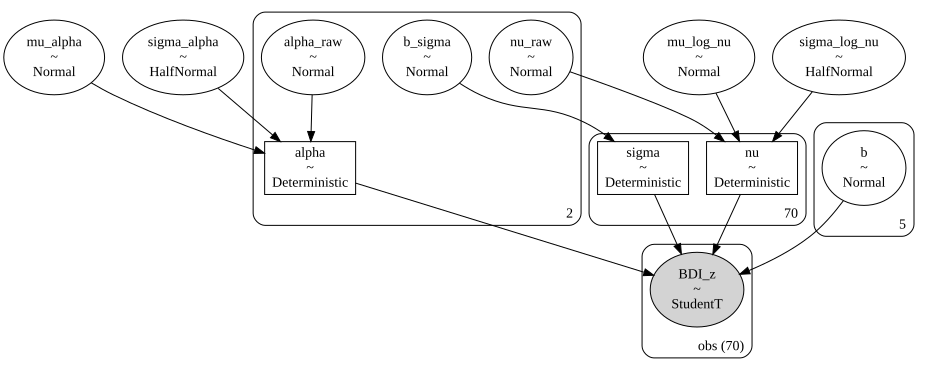

In [47]:
from pymc import model_to_graphviz
model_to_graphviz(model_grp2)

Sampling: [BDI_z, alpha_raw, b, b_sigma, mu_alpha, mu_log_nu, nu_raw, sigma_alpha, sigma_log_nu]


<Axes: xlabel='BDI_z'>

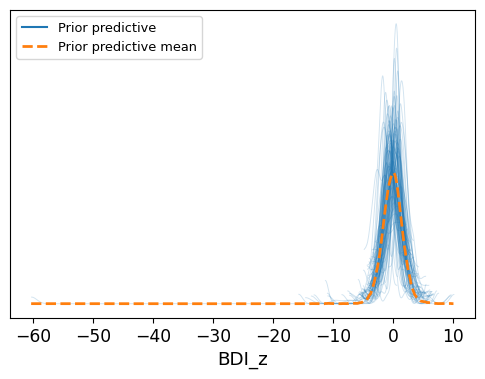

In [36]:
import arviz as az
with model_grp2:
    prior_pred = pm.sample_prior_predictive(samples=100, random_seed=123)

az.plot_ppc(
    prior_pred,
    group="prior",          # <-- important: use prior, not posterior
    data_pairs={"BDI_z": "BDI_z"},  # map model var -> observed name (often auto)
    kind="kde",             # or "hist"
    figsize=(6,4)
)



In [37]:
import numpy as np

# assumes: prior_pred = pm.sample_prior_predictive(...) already run
y_pp = prior_pred.prior_predictive["BDI_z"].stack(sample=("chain","draw")).values
# y_pp shape should be (sample, N) or (sample, ...). Inspect:
print("y_pp shape:", y_pp.shape)

# Flatten everything:
y_pp_flat = np.ravel(y_pp)

# Quick sanity stats
print("min:", y_pp_flat.min(), "max:", y_pp_flat.max())
print("mean:", y_pp_flat.mean(), "std:", y_pp_flat.std())
print("quantiles:", np.percentile(y_pp_flat, [0, 5, 25, 50, 75, 95, 99, 99.9, 99.99]))

# sigma draws
sigma_pp = prior_pred.prior["sigma"].stack(sample=("chain","draw")).values
print("sigma_pp shape:", sigma_pp.shape)
print("sigma min/median/max:", sigma_pp.min(), np.median(sigma_pp), sigma_pp.max())

# nu draws
nu_pp = prior_pred.prior["nu"].stack(sample=("chain","draw")).values
print("nu_pp shape:", nu_pp.shape)
print("nu min/median/max:", nu_pp.min(), np.median(nu_pp), nu_pp.max())



y_pp shape: (70, 100)
min: -60.269162920139465 max: 10.11771371192501
mean: -0.07149108712694224 std: 1.8342972792105363
quantiles: [-6.02691629e+01 -2.67988786e+00 -1.07391230e+00 -2.62797708e-02
  9.40993925e-01  2.54369231e+00  4.11383937e+00  6.66523754e+00
  9.80725333e+00]
sigma_pp shape: (70, 100)
sigma min/median/max: 0.5486022010387035 0.9982466624968854 2.2101844693695414
nu_pp shape: (70, 100)
nu min/median/max: 1.2628820559958829 6.100044530363828 19.147869354786195


In [48]:
import arviz as az
az.summary(idata_grp2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.041,0.358,-0.712,0.644,0.005,0.004,4871.0,4605.0,1.0
alpha_raw[0],1.119,0.619,0.044,2.347,0.009,0.008,4840.0,4415.0,1.0
alpha_raw[1],-1.189,0.614,-2.353,-0.082,0.008,0.008,5463.0,4878.0,1.0
b[0],-0.296,0.124,-0.522,-0.054,0.002,0.002,6186.0,5211.0,1.0
b[1],0.030,0.059,-0.076,0.150,0.001,0.001,9273.0,6084.0,1.0
...,...,...,...,...,...,...,...,...,...
nu[65],9.076,4.544,3.565,16.514,0.051,0.152,9265.0,6398.0,1.0
nu[66],9.076,4.544,3.565,16.514,0.051,0.152,9265.0,6398.0,1.0
nu[67],9.076,4.544,3.565,16.514,0.051,0.152,9265.0,6398.0,1.0
nu[68],9.076,4.544,3.565,16.514,0.051,0.152,9265.0,6398.0,1.0


In [49]:
import arviz as az

mean_terms = [
    "unimodal_z",
    "transmodal_z",
    "age_z",
    "unimodal_z:group_HC",
    "sex"
]


# Beta vector
b_da = idata_grp2.posterior["b"]
# detect the non-sample dim name (e.g., 'b_dim_0')
b_dim_name = [d for d in b_da.dims if d not in ("chain", "draw")][0]

# assign names
idata_grp2.posterior = idata_grp2.posterior.assign_coords(
    {b_dim_name: mean_terms}
)

summary_b = az.summary(idata_grp2, var_names=["b"], hdi_prob=0.95)
print(summary_b)



                         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
b[unimodal_z]          -0.296  0.124    -0.534     -0.044      0.002    0.002   
b[transmodal_z]         0.030  0.059    -0.089      0.147      0.001    0.001   
b[age_z]                0.023  0.051    -0.076      0.123      0.001    0.001   
b[unimodal_z:group_HC]  0.299  0.125     0.052      0.541      0.002    0.001   
b[sex]                  0.001  0.299    -0.605      0.559      0.003    0.004   

                        ess_bulk  ess_tail  r_hat  
b[unimodal_z]             6186.0    5211.0    1.0  
b[transmodal_z]           9273.0    6084.0    1.0  
b[age_z]                  8643.0    5591.0    1.0  
b[unimodal_z:group_HC]    6212.0    5141.0    1.0  
b[sex]                    8951.0    5349.0    1.0  


Computed from 8000 posterior samples and 70 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -44.91     6.66
p_loo        3.91        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       70  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Computed from 8000 posterior samples and 70 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -42.24     6.40
p_loo        3.96        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       70  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

         rank   elpd_loo     p_loo  elpd_diff  weight         se       dse  \
model_2     0  84.473949  3.964926   0.000000     1.0  12.797689  0.000000   
model_1     1  89.821877  3.909373   5.347928     0.0  13.323420  3.780629   

         warning     scale  
model_2    False  deviance  
m

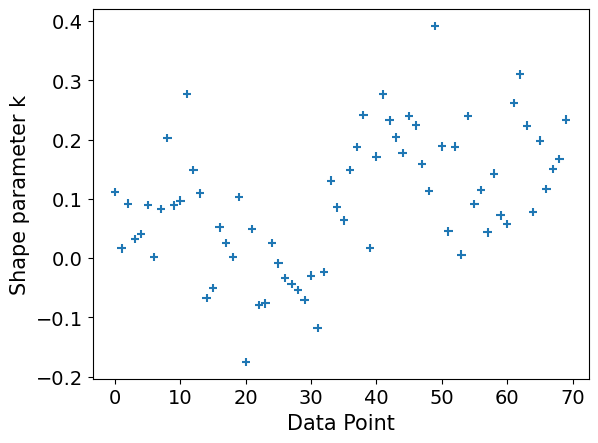

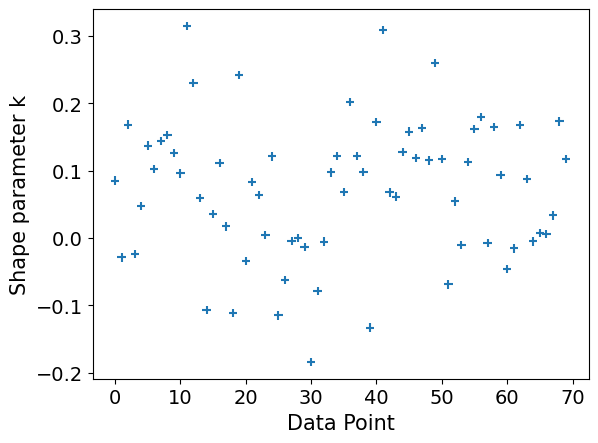

In [53]:
# Compare log likelihood
loo_m1 = az.loo(idata_grp1, pointwise=True)  # PSIS-LOO
loo_m2 = az.loo(idata_grp2, pointwise=True)

print(loo_m1)
print(loo_m2)

# Pareto-k diagnostics
az.plot_khat(loo_m1)
az.plot_khat(loo_m2)

cmp = az.compare(
    {"model_1": idata_grp1, "model_2": idata_grp2},
    ic="loo",            # PSIS-LOO
    scale="deviance",    # reports LOOIC (lower better); use "log" for elpd
    method="stacking"   # model weights; alt: "BB-pseudo-BMA"
  
)
print(cmp)



<xarray.DataArray 'b' (sample: 8000, term: 5)> Size: 320kB
array([[-0.42781691,  0.04437216, -0.0099432 ,  0.42481842,  0.32584746],
       [-0.47027836,  0.07879765,  0.00126479,  0.44705326, -0.03826769],
       [-0.43330931,  0.01623131,  0.129915  ,  0.44547673,  0.12872481],
       ...,
       [-0.40612732,  0.1309732 , -0.11356804,  0.38199579,  0.40133112],
       [-0.27149693, -0.01057987,  0.1082743 ,  0.28530231,  0.08656078],
       [-0.34591438, -0.00271663,  0.08168698,  0.39940452, -0.32363191]])
Coordinates:
  * term     (term) <U19 380B 'unimodal_z' 'transmodal_z' ... 'sex'
  * sample   (sample) object 64kB MultiIndex
  * chain    (sample) int32 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int32 32kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999


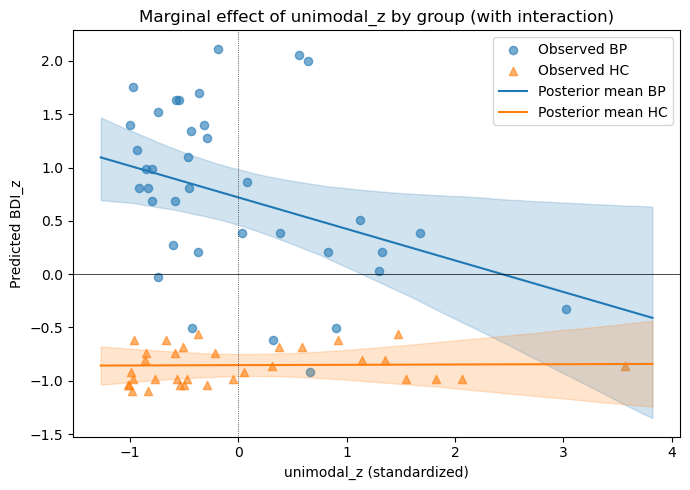

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# -----------------------------
# 0. Sanity: inspect dims
# -----------------------------
# post_s stacks chain+draw to a single 'sample' dim
post_s = idata_grp2.posterior.stack(sample=("chain","draw"))
alpha_da = post_s["alpha"]  # dims: ('group', 'sample')
alpha_da = alpha_da.transpose("sample", "group")  # shape: (samples, groups)
alpha_mat = alpha_da.values  # (samples, 2)
alpha_BP = alpha_mat[:, 0]
alpha_HC = alpha_mat[:, 1]

term_idx = {
    "unimodal_z": 0,
    "transmodal_z": 1,
    "age_z": 2,
    "unimodal_z:group_HC": 3,
    "sex": 4
}

# The beta param
# Extract betas
b_da = post_s["b"].transpose("sample", "term")  # ensures (sample, term)
print(b_da)
b_u   = post_s["b"].sel(term="unimodal_z").values
b_t   = post_s["b"].sel(term="transmodal_z").values
b_a   = post_s["b"].sel(term="age_z").values
b_u_g = post_s["b"].sel(term="unimodal_z:group_HC").values
b_s   = post_s["b"].sel(term="sex").values

u_obs = dat_bmb["unimodal_z"].to_numpy()
u_min, u_max = u_obs.min(), u_obs.max()
u_grid = np.linspace(u_min - 0.25, u_max + 0.25, 100)
u_grid_row = u_grid[None, :]  # (1, G)

T0 = 0.0  # transmodal_z
A0 = 0.0  # age_z
S0 = 0.0  # sex (baseline male?)

# BP group (no interaction)
mu_BP = (
    alpha_BP[:, None]
    + b_u[:, None] * u_grid_row
    + b_t[:, None] * T0
    + b_a[:, None] * A0
    + b_s[:, None] * S0
)

# HC group (interaction active)
mu_HC = (
    alpha_HC[:, None]
    + (b_u[:, None] + b_u_g[:, None]) * u_grid_row
    + b_t[:, None] * T0
    + b_a[:, None] * A0
    + b_s[:, None] * S0
)

def summarize_grid(draws_2d):
    mean_ = draws_2d.mean(axis=0)
    lower = np.quantile(draws_2d, 0.025, axis=0)
    upper = np.quantile(draws_2d, 0.975, axis=0)
    return mean_, lower, upper

bp_mean, bp_lo, bp_hi = summarize_grid(mu_BP)
hc_mean, hc_lo, hc_hi = summarize_grid(mu_HC)

obs_u = dat_bmb["unimodal_z"].to_numpy()
obs_y = dat_bmb["BDI_z"].to_numpy()
obs_group = dat_bmb["group"].to_numpy()

plt.figure(figsize=(7,5))

# Scatter: Observed data
plt.scatter(obs_u[obs_group=="BP"], obs_y[obs_group=="BP"],
            alpha=0.6, s=35, label="Observed BP", marker="o")
plt.scatter(obs_u[obs_group=="HC"], obs_y[obs_group=="HC"],
            alpha=0.6, s=35, label="Observed HC", marker="^")

# Posterior means
plt.plot(u_grid, bp_mean, color="C0", label="Posterior mean BP")
plt.plot(u_grid, hc_mean, color="C1", label="Posterior mean HC")

# Credible intervals
plt.fill_between(u_grid, bp_lo, bp_hi, color="C0", alpha=0.2)
plt.fill_between(u_grid, hc_lo, hc_hi, color="C1", alpha=0.2)

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5, ls=":")
plt.xlabel("unimodal_z (standardized)")
plt.ylabel("Predicted BDI_z")
plt.title("Marginal effect of unimodal_z by group (with interaction)")
plt.legend()
plt.tight_layout()
plt.show()



In [69]:
with model_grp2:
    ppc = pm.sample_posterior_predictive(idata_grp2, var_names=["BDI_z"], random_seed=123)
    idata_grp2.extend(ppc)


Sampling: [BDI_z]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


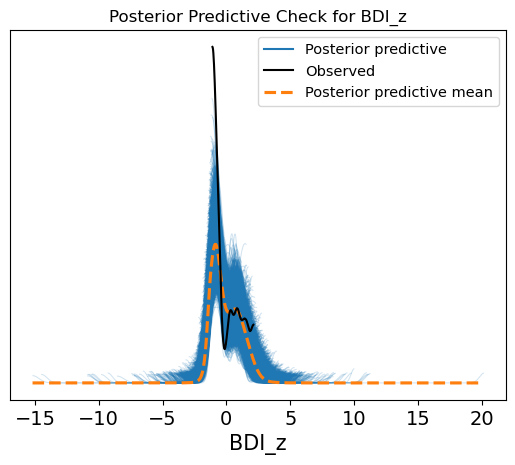

In [70]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_ppc(idata_grp2, group="posterior", data_pairs={"BDI_z": "BDI_z"})
plt.title("Posterior Predictive Check for BDI_z")
plt.show()


In [71]:
import pymc as pm
import arviz as az
import numpy as np

# Extract data
df = dat_bmb.dropna(subset=["unimodal_z", "group"])
y = df["unimodal_z"].values
group = df["group"].values
group_idx = (group == "HC").astype(int)  # 0=BP, 1=HC

coords = {"group": ["BP", "HC"]}

with pm.Model(coords=coords) as model_unimodal:

    # Group-level means
    mu = pm.Normal("mu", mu=0, sigma=1.0, dims="group")
    
    # Common standard deviation
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # Likelihood
    y_obs = pm.Normal("y", mu=mu[group_idx], sigma=sigma, observed=y)

    # Sampling
    idata_unimodal = pm.sample(
        draws=2000, tune=2000, chains=4, target_accept=0.9,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 40 seconds.


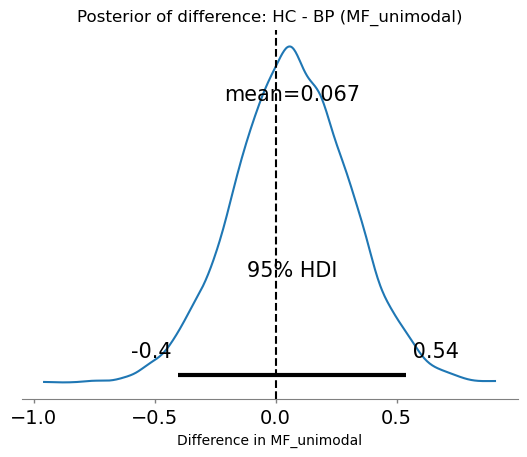

In [72]:
mu_samples = idata_unimodal.posterior["mu"]
diff = mu_samples.sel(group="HC") - mu_samples.sel(group="BP")

az.plot_posterior(diff, hdi_prob=0.95)
plt.title("Posterior of difference: HC - BP (MF_unimodal)")
plt.axvline(0, color="k", ls="--")
plt.xlabel("Difference in MF_unimodal")
plt.show()
